# **Simulating the GCR-2 ansatz on a quantum circuit**

In [31]:
import ffsim
import ffsim.qiskit
import numpy as np
import pyscf
import pyscf.cc
import pyscf.gto
import pyscf.scf
from ffsim.qiskit.gates import PrepareHartreeFockJW
from ffsim.qiskit.gates.ucj import UCJOpSpinBalancedJW
from qiskit import QuantumCircuit

from xquces.igcr2 import IGCR2SpinBalancedParameterization
from xquces.qiskit import CircuitStatsJob, pretty_print_circuit_stats
from xquces.qiskit.gates.igcr2 import igcr2_stateprep_jw_circuit
from xquces.ucj.init import _ucj_ansatz_from_ffsim_stock


# **Nitrogen molecule: cc-pVDZ - equilibrium**

In [32]:
R = 1.1
basis = "cc-pvdz"
threads = 48
optimization_level = 3
transpile_seed = 12345


def build_ffsim_ucj_seed(t2, t1):
    return ffsim.UCJOpSpinBalanced.from_t_amplitudes(
        np.asarray(t2, dtype=np.float64),
        t1=np.asarray(t1, dtype=np.complex128),
        n_reps=1,
    )


def ffsim_ucj_stateprep_jw_circuit(ucj_op, nelec):
    circuit = QuantumCircuit(2 * ucj_op.norb)
    circuit.append(PrepareHartreeFockJW(ucj_op.norb, nelec), circuit.qubits)
    circuit.append(UCJOpSpinBalancedJW(ucj_op), circuit.qubits)
    return circuit


def build_n2_circuits(r, basis):
    mol = pyscf.gto.Mole()
    mol.build(
        atom=[("N", (-0.5 * r, 0, 0)), ("N", (0.5 * r, 0, 0))],
        basis=basis,
        symmetry="Dooh",
        verbose=0,
    )

    scf = pyscf.scf.RHF(mol)
    scf.kernel()

    active_space = list(range(2, mol.nao_nr()))
    norb = len(active_space)
    nelectron_cas = int(round(sum(scf.mo_occ[active_space])))
    n_alpha = (nelectron_cas + mol.spin) // 2
    n_beta = (nelectron_cas - mol.spin) // 2
    nelec = (n_alpha, n_beta)

    ccsd = pyscf.cc.RCCSD(
        scf,
        frozen=[i for i in range(mol.nao_nr()) if i not in active_space],
    )
    ccsd.kernel()

    ffsim_ucj_seed = build_ffsim_ucj_seed(ccsd.t2, ccsd.t1)
    if ffsim_ucj_seed.final_orbital_rotation is None:
        raise RuntimeError("Expected ffsim UCJ seed to include a final orbital rotation.")

    ucj_seed = _ucj_ansatz_from_ffsim_stock(ffsim_ucj_seed)
    igcr2_param = IGCR2SpinBalancedParameterization(norb=norb, nocc=n_alpha)
    x_seed = igcr2_param.parameters_from_ucj_ansatz(ucj_seed)
    igcr2_ansatz = igcr2_param.ansatz_from_parameters(x_seed)

    return (
        ffsim_ucj_stateprep_jw_circuit(ffsim_ucj_seed, nelec),
        igcr2_stateprep_jw_circuit(igcr2_ansatz),
        norb,
        nelec,
        ffsim_ucj_seed.n_params(norb=norb, n_reps=1, with_final_orbital_rotation=True),
        igcr2_param.n_params,
    )

ffsim_circuit, igcr2_circuit, norb, nelec, ucj_n_params, igcr2_n_params = build_n2_circuits(
    r=R,
    basis=basis,
)

title = (
    f"N2/{basis} state-preparation circuit stats "
    f"(R={R:.3f} A, norb={norb}, nelec={nelec})"
)
print(f"parameters: ffsim UCJ = {ucj_n_params}, iGCR2 = {igcr2_n_params}\n")
pretty_print_circuit_stats(
    [
        CircuitStatsJob(
            "ffsim UCJ spin-balanced stateprep before PRE_INIT",
            ffsim_circuit,
        ),
        CircuitStatsJob(
            "ffsim UCJ spin-balanced stateprep after PRE_INIT",
            ffsim_circuit,
            pre_init=ffsim.qiskit.PRE_INIT,
        ),
        CircuitStatsJob("iGCR2 stateprep plain", igcr2_circuit),
    ],
    title=title,
    optimization_level=optimization_level,
    seed=transpile_seed,
)


parameters: ffsim UCJ = 2054, iGCR2 = 1484

N2/cc-pvdz state-preparation circuit stats (R=1.100 A, norb=26, nelec=(5, 5))
ffsim UCJ spin-balanced stateprep before PRE_INIT
-------------------------------------------------
qubits:          52
depth:           833
gates:           22477
two-qubit gates: 4068
ops:             cx: 4068, rz: 9942, sx: 8403, x: 64

ffsim UCJ spin-balanced stateprep after PRE_INIT
------------------------------------------------
qubits:          52
depth:           548
gates:           11467
two-qubit gates: 2064
ops:             cx: 2064, rz: 5048, sx: 4316, x: 39

iGCR2 stateprep plain
---------------------
qubits:          52
depth:           507
gates:           10748
two-qubit gates: 1968
ops:             cx: 1968, rz: 4640, sx: 4118, x: 22


[CircuitStats(label='ffsim UCJ spin-balanced stateprep before PRE_INIT', num_qubits=52, depth=833, gate_count=22477, two_qubit_gate_count=4068, count_ops={'rz': 9942, 'sx': 8403, 'cx': 4068, 'x': 64}),
 CircuitStats(label='ffsim UCJ spin-balanced stateprep after PRE_INIT', num_qubits=52, depth=548, gate_count=11467, two_qubit_gate_count=2064, count_ops={'rz': 5048, 'sx': 4316, 'cx': 2064, 'x': 39}),
 CircuitStats(label='iGCR2 stateprep plain', num_qubits=52, depth=507, gate_count=10748, two_qubit_gate_count=1968, count_ops={'rz': 4640, 'sx': 4118, 'cx': 1968, 'x': 22})]

# **Hydrogen circuit visualization and comparisons**

In [ ]:
def build_h2_circuits(r, basis):
    mol = pyscf.gto.Mole()
    mol.build(
        atom=[("H", (-0.5 * r, 0, 0)), ("H", (0.5 * r, 0, 0))],
        basis=basis,
        symmetry="Dooh",
        verbose=0,
    )

    scf = pyscf.scf.RHF(mol)
    scf.kernel()

    active_space = list(range(mol.nao_nr()))
    norb = len(active_space)
    nelectron_cas = int(round(sum(scf.mo_occ[active_space])))
    n_alpha = (nelectron_cas + mol.spin) // 2
    n_beta = (nelectron_cas - mol.spin) // 2
    nelec = (n_alpha, n_beta)

    ccsd = pyscf.cc.RCCSD(scf)
    ccsd.kernel()

    ffsim_ucj_seed = build_ffsim_ucj_seed(ccsd.t2, ccsd.t1)
    if ffsim_ucj_seed.final_orbital_rotation is None:
        raise RuntimeError("Expected ffsim UCJ seed to include a final orbital rotation.")

    ucj_seed = _ucj_ansatz_from_ffsim_stock(ffsim_ucj_seed)
    igcr2_param = IGCR2SpinBalancedParameterization(norb=norb, nocc=n_alpha)
    x_seed = igcr2_param.parameters_from_ucj_ansatz(ucj_seed)
    igcr2_ansatz = igcr2_param.ansatz_from_parameters(x_seed)

    return (
        ffsim_ucj_stateprep_jw_circuit(ffsim_ucj_seed, nelec),
        igcr2_stateprep_jw_circuit(igcr2_ansatz),
        norb,
        nelec,
        ffsim_ucj_seed.n_params(norb=norb, n_reps=1, with_final_orbital_rotation=True),
        igcr2_param.n_params,
    )


In [41]:
h2_R = 0.74
h2_basis = "sto-6g"

h2_ffsim_circuit, h2_igcr2_circuit, h2_norb, h2_nelec, h2_ucj_n_params, h2_igcr2_n_params = build_h2_circuits(
    r=h2_R,
    basis=h2_basis,
)

print(f"\nH2/{h2_basis} visualization circuits (R={h2_R:.3f} A, norb={h2_norb}, nelec={h2_nelec})")
print(f"parameters: ffsim UCJ = {h2_ucj_n_params}, iGCR2 = {h2_igcr2_n_params}")

h2_ffsim_givens_circuit = h2_ffsim_circuit.decompose(reps=2)
h2_igcr2_givens_circuit = h2_igcr2_circuit.decompose(reps=1)


H2/sto-6g visualization circuits (R=0.740 A, norb=2, nelec=(1, 1))
parameters: ffsim UCJ = 14, iGCR2 = 5


# ffsim UCJ

ffsim visible ops: {'p': 16, 'xx_plus_yy': 6, 'cp': 6, 'x': 2, 'global_phase': 1}


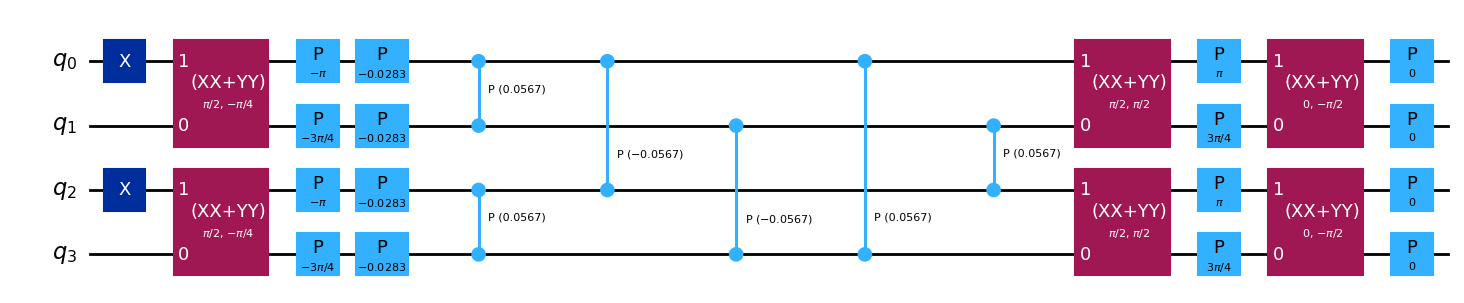

In [42]:
print("ffsim visible ops:", dict(h2_ffsim_givens_circuit.count_ops()))
h2_ffsim_givens_circuit.draw("mpl", fold=-1, idle_wires=False)

# ffsim UCJ after pre_init

ffsim after PRE_INIT visible ops: {'p': 8, 'cp': 6, 'xx_plus_yy': 4, 'x': 2, 'global_phase': 1}


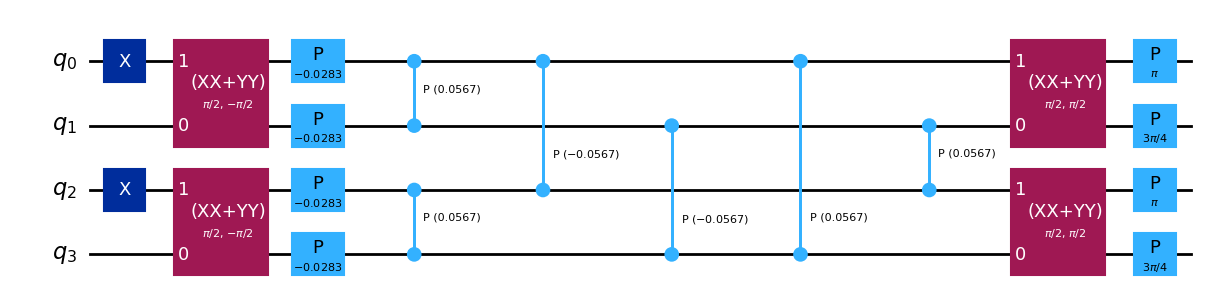

In [43]:
import ffsim.qiskit

h2_ffsim_after_pre_init_givens = ffsim.qiskit.PRE_INIT.run(h2_ffsim_circuit)

print("ffsim after PRE_INIT visible ops:", dict(h2_ffsim_after_pre_init_givens.decompose(reps=1).count_ops()))
h2_ffsim_after_pre_init_givens.decompose(reps=1).draw("mpl", fold=-1, idle_wires=False)

# xquces iGCR-2

iGCR2 visible ops: {'xx_plus_yy': 4, 'p': 4, 'x': 2, 'rzz': 2, 'global_phase': 1}


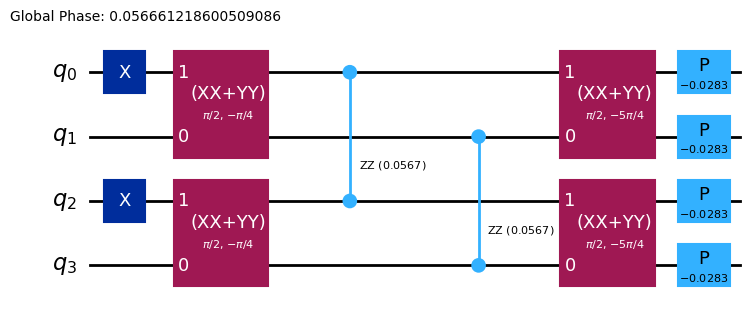

In [44]:
print("iGCR2 visible ops:", dict(h2_igcr2_givens_circuit.count_ops()))
h2_igcr2_givens_circuit.draw("mpl", fold=-1, idle_wires=False)

In [49]:
from qiskit.quantum_info import Statevector
from xquces.basis import occ_rows
from xquces.hamiltonians import MolecularHamiltonianLinearOperator


def bitstring_index(occ_alpha, occ_beta, norb):
    alpha_bits = sum(1 << int(p) for p in occ_alpha)
    beta_bits = sum(1 << (norb + int(p)) for p in occ_beta)
    return alpha_bits + beta_bits


def jw_state_to_sector(vec, norb, nelec):
    occ_alpha = occ_rows(norb, nelec[0])
    occ_beta = occ_rows(norb, nelec[1])
    out = np.zeros((len(occ_alpha), len(occ_beta)), dtype=np.complex128)

    for i_alpha, alpha in enumerate(occ_alpha):
        for i_beta, beta in enumerate(occ_beta):
            out[i_alpha, i_beta] = vec[bitstring_index(alpha, beta, norb)]

    return out.reshape(-1)


def stateprep_sector_state(circuit, norb, nelec):
    full_state = Statevector.from_label("0" * (2 * norb)).evolve(circuit).data
    return jw_state_to_sector(full_state, norb, nelec)


def phase_aligned_diff(psi, phi):
    overlap = np.vdot(phi, psi)
    if abs(overlap) < 1e-14:
        return np.linalg.norm(psi - phi)
    return np.linalg.norm(psi - overlap / abs(overlap) * phi)


# Rebuild the H2 SCF object for the Hamiltonian.
h2_mol = pyscf.gto.Mole()
h2_mol.build(
    atom=[("H", (-0.5 * h2_R, 0, 0)), ("H", (0.5 * h2_R, 0, 0))],
    basis=h2_basis,
    symmetry="Dooh",
    verbose=0,
)

h2_scf = pyscf.scf.RHF(h2_mol)
h2_scf.kernel()

h2_active_space = list(range(h2_mol.nao_nr()))
h2_ham = MolecularHamiltonianLinearOperator.from_scf(
    h2_scf,
    active_space=h2_active_space,
)

# Use the ffsim PRE_INIT-only circuit if you built it already.
h2_ffsim_after_pre_init_givens = ffsim.qiskit.PRE_INIT.run(h2_ffsim_circuit).decompose(reps=1)

psi_ffsim_before = stateprep_sector_state(h2_ffsim_circuit, h2_norb, h2_nelec)
psi_ffsim_after = stateprep_sector_state(h2_ffsim_after_pre_init_givens, h2_norb, h2_nelec)
psi_igcr2 = stateprep_sector_state(h2_igcr2_circuit, h2_norb, h2_nelec)

states = {
    "ffsim before PRE_INIT": psi_ffsim_before,
    "ffsim after PRE_INIT": psi_ffsim_after,
    "iGCR2": psi_igcr2,
}

reference_name = "ffsim before PRE_INIT"
reference_state = states[reference_name]

print("Energies")
print("--------")
for name, psi in states.items():
    energy = h2_ham.expectation(psi)
    print(f"{name:24s}: {energy:.16f}")

print()
print(f"Overlaps with {reference_name}")
print("--------------------------------")
for name, psi in states.items():
    overlap = np.vdot(reference_state, psi)
    print(
        f"{name:24s}: "
        f"|overlap| = {abs(overlap):.16f}, "
        f"phase-aligned diff = {phase_aligned_diff(psi, reference_state):.3e}"
    )

print("\nParameters")
print("----------")
print(f"ffsim UCJ: {h2_ucj_n_params}")
print(f"iGCR2:     {h2_igcr2_n_params}")

print()
print("Circuit stats")
print("-------------")
print(
    f"{'circuit':28s} "
    f"{'depth':>8s} "
    f"{'gates':>8s} "
    f"{'ops'}"
)

for name, circuit in [
    ("ffsim before PRE_INIT", h2_ffsim_givens_circuit),
    ("ffsim after PRE_INIT", h2_ffsim_after_pre_init_givens),
    ("iGCR2", h2_igcr2_givens_circuit),
]:
    ops = dict(circuit.count_ops())
    gate_count = sum(ops.values())
    ops_text = ", ".join(f"{gate}: {count}" for gate, count in sorted(ops.items()))
    print(f"{name:28s} {circuit.depth():8d} {gate_count:8d} {ops_text}")


Energies
--------
ffsim before PRE_INIT   : -1.1408254570223193
ffsim after PRE_INIT    : -1.1408254570223193
iGCR2                   : -1.1408254570223204

Overlaps with ffsim before PRE_INIT
--------------------------------
ffsim before PRE_INIT   : |overlap| = 1.0000000000000002, phase-aligned diff = 0.000e+00
ffsim after PRE_INIT    : |overlap| = 1.0000000000000002, phase-aligned diff = 2.249e-16
iGCR2                   : |overlap| = 1.0000000000000004, phase-aligned diff = 5.415e-16

Parameters
----------
ffsim UCJ: 14
iGCR2:     5

Circuit stats
-------------
circuit                         depth    gates ops
ffsim before PRE_INIT              11       31 cp: 6, global_phase: 1, p: 16, x: 2, xx_plus_yy: 6
ffsim after PRE_INIT                8       21 cp: 6, global_phase: 1, p: 8, x: 2, xx_plus_yy: 4
iGCR2                               5       13 global_phase: 1, p: 4, rzz: 2, x: 2, xx_plus_yy: 4
